## Python Applied Data Science Project
### Sales Analysis

#### Preparation

In [1]:
# Importing Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [2]:
# Getting the data
sales = pd.read_csv("AusApparalSales4thQrt2020.csv")

# Prepring the Data
sales['Date'] = pd.to_datetime(sales['Date'])
pd.options.display.float_format = '{:.2f}'.format

# Generating additional data for more detailed analysis
sales['Week'] = sales['Date'].dt.isocalendar().week
sales['Month'] = pd.to_datetime(sales['Date']).dt.month_name()
sales['Quarter'] = pd.PeriodIndex(sales['Date'], freq='Q')
sales['Is Weekend'] = sales['Date'].dt.dayofweek > 4

In [3]:
# Check for NA
sales.isna().sum()

Date          0
Time          0
State         0
Group         0
Unit          0
Sales         0
Week          0
Month         0
Quarter       0
Is Weekend    0
dtype: int64

In [4]:
# Verify Sales to Unit Ratio
(sales["Sales"]/sales["Unit"]).unique()

array([2500.])

Given the fact that the **Sales** to **Unit** Ratio is equal throughout, we can deduce that each **Unit** is worth 2500 units of **Sales**.
Hence, going forward, only **Unit** will be used for all visual calculations.

#### A Preview of the Prepared Data

In [5]:
sales

,Date,Time,State,Group,Unit,Sales,Week,Month,Quarter,Is Weekend
0,2020-10-01,Morning,WA,Kids,8,20000,40,October,2020Q4,False
1,2020-10-01,Morning,WA,Men,8,20000,40,October,2020Q4,False
2,2020-10-01,Morning,WA,Women,4,10000,40,October,2020Q4,False
3,2020-10-01,Morning,WA,Seniors,15,37500,40,October,2020Q4,False
4,2020-10-01,Afternoon,WA,Kids,3,7500,40,October,2020Q4,False
...,...,...,...,...,...,...,...,...,...,...
7555,2020-12-30,Afternoon,TAS,Seniors,14,35000,53,December,2020Q4,False
7556,2020-12-30,Evening,TAS,Kids,15,37500,53,December,2020Q4,False
7557,2020-12-30,Evening,TAS,Men,15,37500,53,December,2020Q4,False
7558,2020-12-30,Evening,TAS,Women,11,27500,53,December,2020Q4,False


### Unit Sales Analysis
#### Daily Average Units Sold during the Quarter

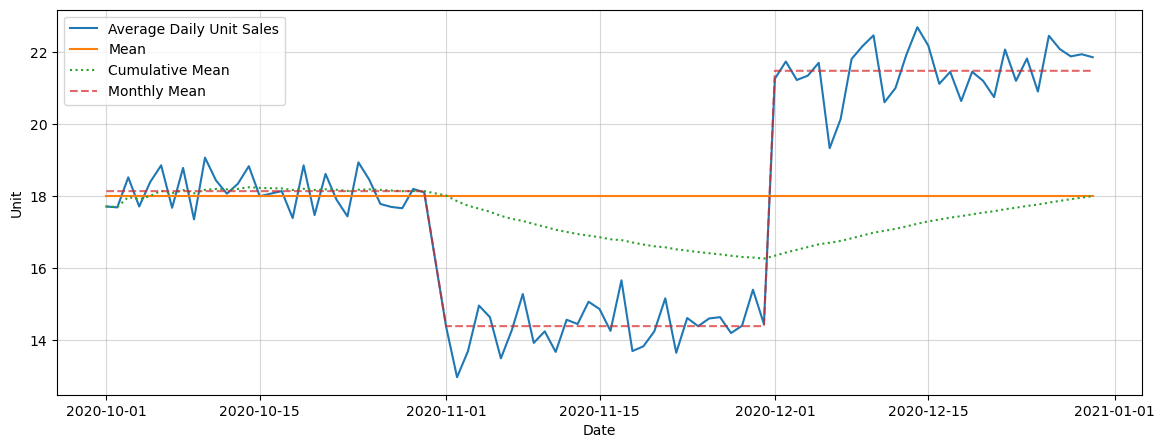

In [6]:
monthly_units_avg = sales.groupby("Month")["Unit"].mean().reset_index()
daywise_sales = sales.groupby(by=["Date"], sort=False).agg({"Unit":"mean"}).reset_index()
daywise_sales['C_Mean'] = daywise_sales["Unit"].expanding().mean()
daywise_sales['Month'] = pd.to_datetime(daywise_sales['Date']).dt.month_name()

# Create a dictionary from 'monthly_units_avg' with 'Month' as keys and 'Unit' as values
month_unit_dict = dict(zip(monthly_units_avg['Month'], monthly_units_avg['Unit']))

# Create a new 'M_mean' column in 'daywise_sales' by mapping the 'Month' column to the dictionary
daywise_sales['M_mean'] = daywise_sales['Month'].map(month_unit_dict)

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=daywise_sales, x="Date", y="Unit", legend="auto", label="Average Daily Unit Sales")
sns.lineplot(data=daywise_sales, x="Date", y=daywise_sales["Unit"].mean(), label="Mean")
sns.lineplot(data=daywise_sales, x="Date", y="C_Mean", label="Cumulative Mean", linestyle="dotted")
sns.lineplot(data=daywise_sales, x="Date", y="M_mean", label="Monthly Mean", linestyle="dashed", alpha=0.7)
plt.grid(alpha=0.5)
plt.show()

#### Weekly Average Units Sold

<Axes: xlabel='Week', ylabel='Unit'>

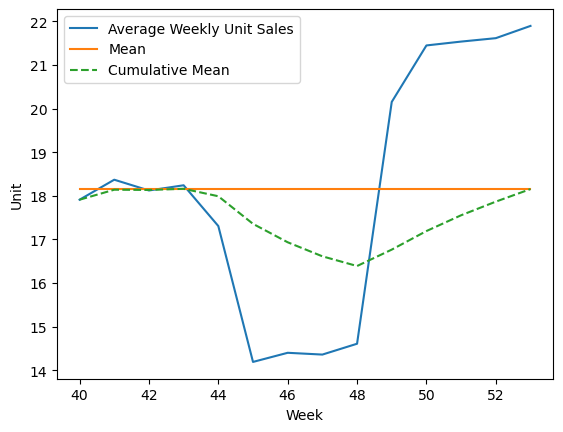

In [7]:
weekwise_units = sales.groupby(by=["Week"], sort=False).agg({"Unit":"mean"})
weekwise_units['C_Mean'] = weekwise_units["Unit"].expanding().mean()
sns.lineplot(data=weekwise_units, x="Week", y="Unit", legend="auto", label="Average Weekly Unit Sales")
sns.lineplot(data=weekwise_units, x="Week", y=weekwise_units["Unit"].mean(), label="Mean")
sns.lineplot(data=weekwise_units, x="Week", y="C_Mean", label="Cumulative Mean", linestyle="dashed")

Based on the graphs:
- Sales are average during October
- Sales drop during November. This could be due to the people saving up for the upcoming festive season.
- Sales are high during the month of December. This could be due to festivals and holidays.

#### Boxplot and Bar graph of average Units sold in each State

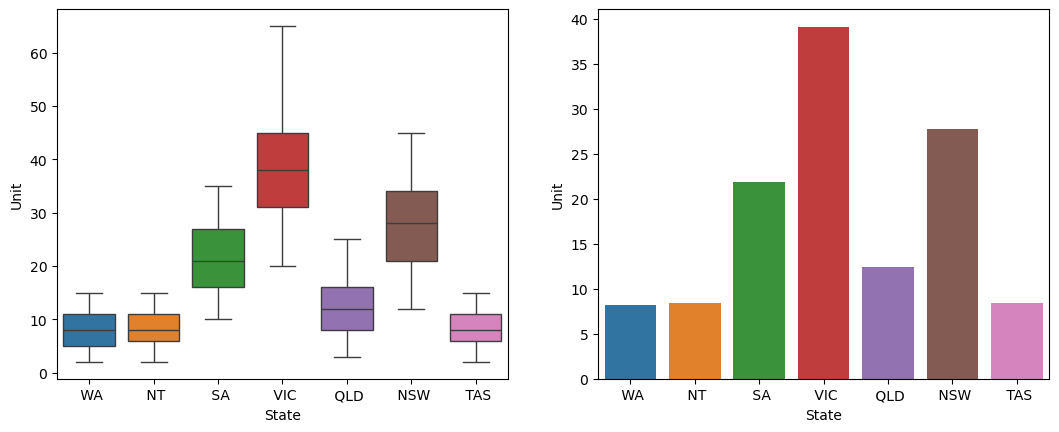

In [8]:
plt.subplots(1, 2, figsize=(12.8, 4.8))
plt.subplot(1,2,1)
sns.boxplot(data=sales, x="State", y="Unit", hue="State" )

plt.subplot(1,2,2)
statewise_units = sales.groupby(by=["State"], sort=False).agg({"Unit":"mean"})
sns.barplot(data=statewise_units, x="State", y="Unit", hue="State")
plt.show()

Based on the graphs:
- There are no outliers in the data.
- Sales are high in the **VIC** State. Hence, **VIC** State would be the ideal place for the planned expansion given its high population density.
- The State of **NSW** has the second highest sales in Australia. The state has a lower population density, but higher population. This state would also be a good place for expansion if the products can reach a wider population, especially in an area of the state with a relatively higher population density.
- The states of **WA**, **NT**, and **TAS** are the states with the lowest sales. **WA** and **NT** have lower population densities that might explain the low sales. **TAS**, on the other hand has a higher population density than **SA** and **QLD**, which have higher sales. More information may be required to determine why the sales in **TAS** are low. e.g. Store location, population density around the store, local competition, average income per household and product pricing, etc.

#### Heatmap of Unit sales for each State grouped by Month

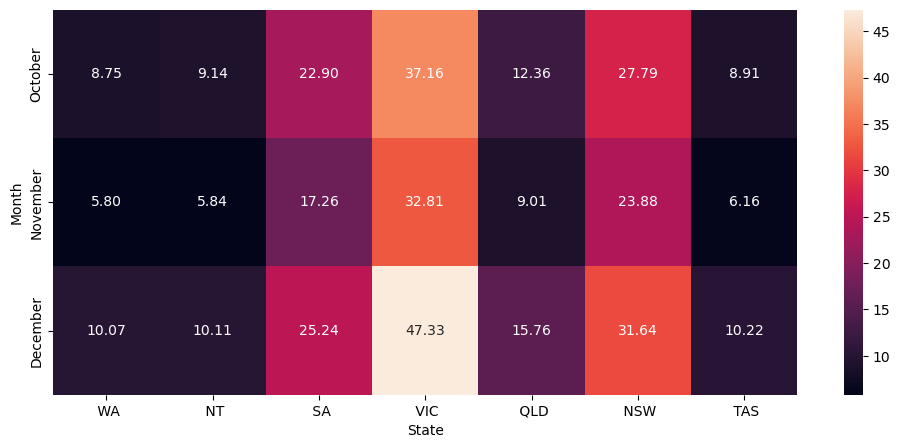

In [9]:
monthwise_states = sales.pivot_table(values="Unit", index=["Month"], columns=["State"], aggfunc="mean", sort=False)
plt.subplots(figsize=(12, 5))
sns.heatmap(monthwise_states, annot=True, fmt='.2f')
plt.show()

The general trend for each state remains the same with, October showing average sales, November showing the lowest sales, and December showing the highest sales.

#### Heatmap of Unit sales for each State grouped by Time of day

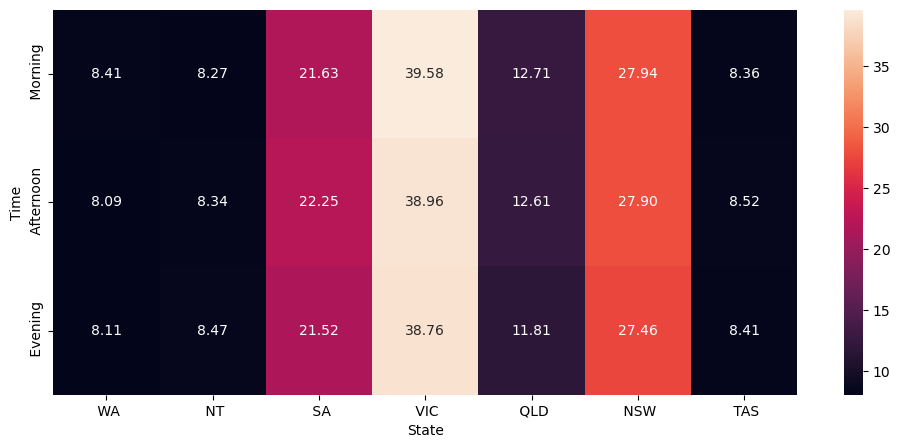

In [10]:
timewise_states = sales.pivot_table(values="Unit", index=["Time"], columns=["State"], aggfunc="mean", sort=False)
plt.subplots(figsize=(12, 5))
sns.heatmap(timewise_states, annot=True, fmt='.2f')
plt.show()

No discernable data or pattern was obtained from the above data.

#### Bar graph of Unit sales based on Time of day

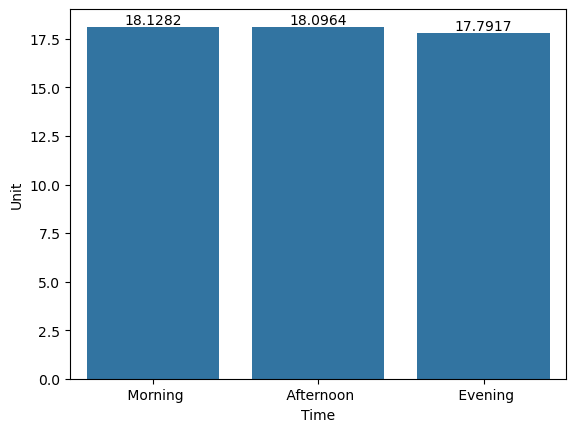

In [12]:
timewise_sales = sales.groupby(by=["Time"], sort=False).agg({"Unit":"mean"})

ax = sns.barplot(data=timewise_sales, x="Time", y="Unit")

ax.bar_label(ax.containers[0])
plt.show()

Based on the graphs:
- On an average, sales are highest in the Morning.
- On an average, sales are lowest in the Evening.
- The highest and lowest values have very little difference.

#### Heatmap of Unit sales for each Month grouped by Time of day

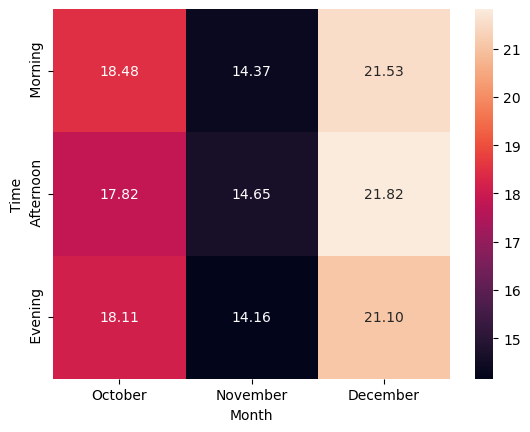

In [13]:
monthwise_time = sales.pivot_table(values="Unit", index=["Time"], columns=["Month"], aggfunc="mean", sort=False)
sns.heatmap(monthwise_time, annot=True, fmt='.2f')
plt.show()

Sales in the Afternoon are higher in November and December than in October. This could be attributed to the colder weather during the later months, when people would like to get out more during the day, when it is warmer and the sun is present.

#### Grouped Bar Graph and Heatmap of Unit sales for each State grouped by Target Group

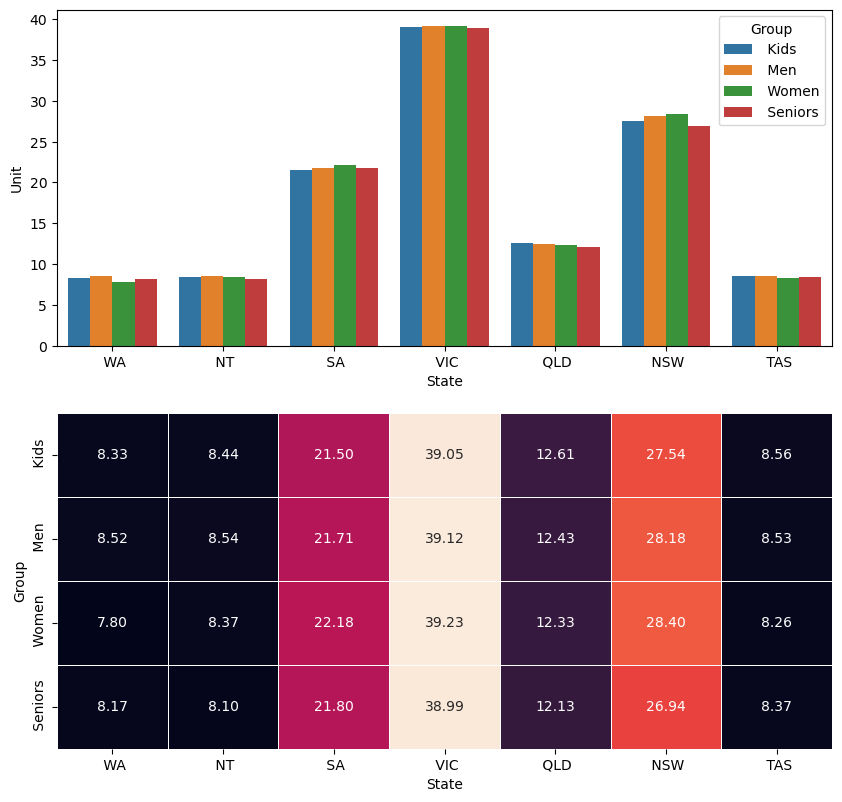

In [14]:
statewise_group = sales.groupby(by = ["State", "Group"], sort=False).agg({'Unit': 'mean'}).reset_index()
statewise_group2 = sales.pivot_table(values="Unit", index=["Group"], columns=["State"], aggfunc="mean", sort=False)

fig, ax = plt.subplots(2, 1, figsize=(10, 9.6))
plt.subplot(2,1,1)
sns.barplot(data=statewise_group, x="State", y="Unit", hue="Group")

plt.subplot(2,1,2)
sns.heatmap(statewise_group2, annot=True, fmt='.2f', linewidths=0.5, cbar=False)
plt.show()

Based on the graph -
- Sales for **Kids** group is slightly higher in **QLD**.
- Sales for **Kids** group is lowest in **WA** among all states.
- Sales for **Men** group is slightly higher in **WA**.
- Sales for **Women** group is higher in **NSW** and **SA**, and lower is **WA**.
- Sales for **Women** group is lowest in **WA** among all states and among all Groups in **WA**.
- Sales for **Seniors** group is lower in **NSW**.
- All other Sales are roughly equal in each State.

**Note**: Since the Sales-to-Unit ratio is constant, the value of Sales can be found by multiplying **2500** to the values.

#### Grouped Bar Graph of Unit sales for each Month grouped by Target Group

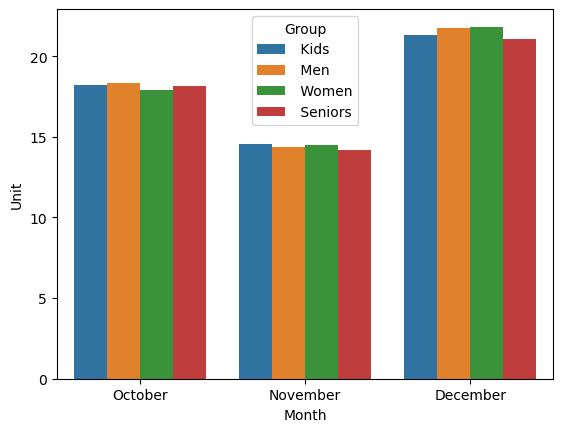

In [15]:
monthwise_group = sales.groupby(by = ["Month", "Group"], sort=False).agg({'Unit': 'mean'}).reset_index()
sns.barplot(data=monthwise_group, x="Month", y="Unit", hue="Group")
plt.show()

Based on the graph -
- Sales for **Women** group is higher during **December**. This could be due to the arrival of Winter Collection.
- Sales for **Seniors** group is lower during **November** and **December**, which may be attributed to the colder weather.
- All other Sales are roughly equal for each Month.

#### Bar Graph of Unit sales for each Target Group

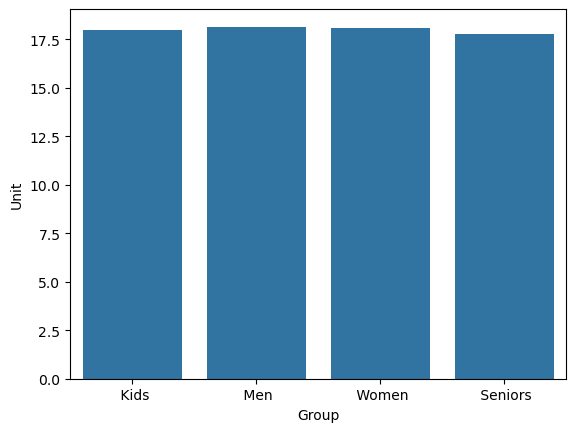

In [16]:
groupwise_sales = sales.groupby(by=["Group"], sort=False).agg({"Unit":"mean"}).reset_index()
sns.barplot(data=groupwise_sales, x="Group", y="Unit")
plt.show()

The Sales of each group during the observation period are roughly equal.

#### Bar graph of Unit sales on Weekdays vs. Weekends grouped by Target Group

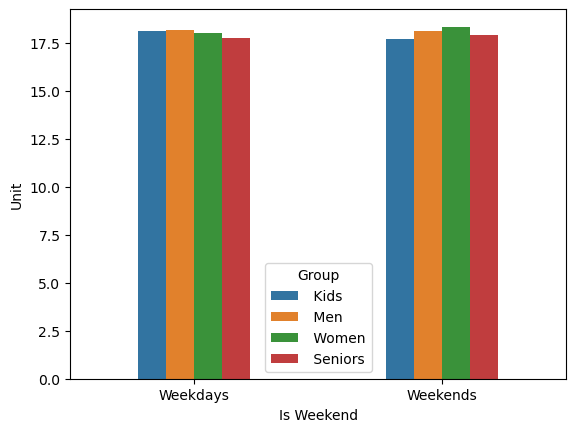

In [17]:
fig, ax = plt.subplots()
ax.set_xticks([False, True])
ax.set_xticklabels(["Weekdays", "Weekends"]) 
weekend_sales = sales.groupby(by=["Is Weekend", "Group"], sort=False).agg({"Unit":"mean"}).reset_index()
sns.barplot(data=weekend_sales, x="Is Weekend", y="Unit", hue="Group" , width=0.45)
plt.show()

Based on the graph -
- Sales for **Women** group is higher during Weekends.
- Sales for **Kids** and **Men** group is slightly higher during Weekdays.

#### Bar graph of Unit sales for each State grouped by whether the day was a weekend

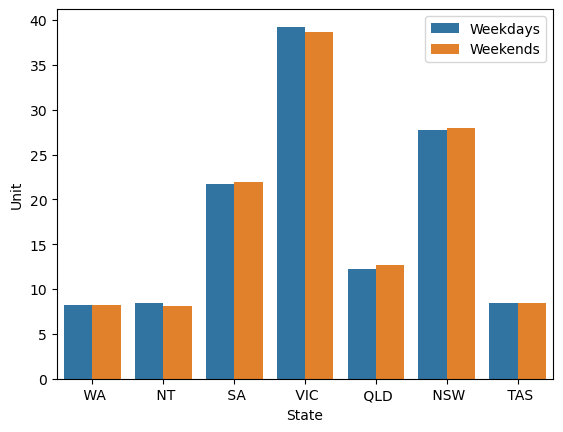

In [18]:
statewise_weekend = sales.groupby(by=["State", "Is Weekend"], sort=False).agg({"Unit":"mean"}).reset_index()
wknd_states = sns.barplot(data=statewise_weekend, x="State", y="Unit", hue="Is Weekend")
legend_handles, _= wknd_states.get_legend_handles_labels()
wknd_states.legend(legend_handles, ['Weekdays','Weekends'])
plt.show()

Based on the graph -
- For the states of **SA**, **QLD** and **NSW**, the sales are higher on weekends.
- For the states of **NT** and **VIC**, the sales are higher on weekdays.
- Sales on weekdays and weekends re roughly equal in the states of **WA** and **TAS**.

### Numerical Reports

In [20]:
# Sum and Mode of Sales and Unit columns.
print("Sum\n", sales[["Unit", "Sales"]].sum())
print("\nMode\n", sales[["Unit", "Sales"]].mode())

Sum
 Unit        136121
Sales    340302500
dtype: int64

Mode
    Unit  Sales
0     9  22500


In [21]:
# Describe the two columns using pandas
sales[["Unit", "Sales"]].describe().round(2)

,Unit,Sales
count,7560.00,7560.00
mean,18.01,45013.56
std,12.90,32253.51
min,2.00,5000.00
25%,8.00,20000.00
50%,14.00,35000.00
75%,26.00,65000.00
max,65.00,162500.00


#### Sales
- Sum - **340302500**
- Mean - **45013.56**
- Median - **35000**
- Mode - **22500**
- Standard Deviation - **32253.51**

#### Units
- Sum - **136121**
- Mean - **18.01**
- Median - **14**
- Mode - **9**
- Standard Deviation - **12.90**

In [25]:
# Sum of sales for each group
sales.groupby(by=["Group"], sort=False).agg({"Unit":["sum"], "Sales":["sum"]})

,Unit,Sales
,sum,sum
Group,,
Kids,34029,85072500
Men,34300,85750000
Women,34177,85442500
Seniors,33615,84037500


#### Identifying Groups
- The group with the highest sales is **Men**.
- The group with the lowest sales is **Seniors**.

#### Quarterly Report

In [26]:
sales.groupby(by=["Quarter"], sort=False).agg({"Unit":["sum", "mean"], "Sales":["sum", "mean"]})

Unit            Sales         
            sum  mean        sum     mean
Quarter                                  
2020Q4   136121 18.01  340302500 45013.56

#### Monthly Report

In [27]:
sales.groupby(by=["Month"], sort=False).agg({"Unit":["sum", "mean"], "Sales":["sum", "mean"]})

Unit            Sales         
            sum  mean        sum     mean
Month                                    
October   45716 18.14  114290000 45353.17
November  36273 14.39   90682500 35985.12
December  54132 21.48  135330000 53702.38

#### Weekly Report

In [28]:
sales.groupby(by=["Week"], sort=False).agg({"Unit":["sum", "mean"], "Sales":["sum", "mean"]})

Unit           Sales         
        sum  mean       sum     mean
Week                                
40     6018 17.91  15045000 44776.79
41    10801 18.37  27002500 45922.62
42    10656 18.12  26640000 45306.12
43    10726 18.24  26815000 45603.74
44     8723 17.31  21807500 43268.85
45     8346 14.19  20865000 35484.69
46     8469 14.40  21172500 36007.65
47     8445 14.36  21112500 35905.61
48     8591 14.61  21477500 36526.36
49    11849 20.15  29622500 50378.40
50    12610 21.45  31525000 53613.95
51    12662 21.53  31655000 53835.03
52    12708 21.61  31770000 54030.61
53     5517 21.89  13792500 54732.14

### Conclusion
- Sales are high in the **VIC** State. Hence, **VIC** State would be the ideal place for the planned expansion given its high population density.
- The State of **NSW** has the second highest sales in Australia. The state has a lower population density, but higher population. This state would also be a good place for expansion if the products can reach a wider population, especially in an area of the state with a relatively higher population density.
- The state of **TAS** has a higher population density than **SA** and **QLD**, which have higher sales. More information may be required to determine why the sales in **TAS** are low. e.g. Store location, population density around the store, local competition, average income per household and product pricing, etc.
- The states of **WA**, **NT**, and **TAS** are the states with the lowest sales.
- Sales for **Kids** group is lowest in **WA** among all states.
- Sales for **Women** group is lowest in **WA** among all states and among all Groups in WA. Introduction of more offers for **Women** group may be needed in the stores in **WA** to attract more women.